# Monte Carlo Sampling and MCMC


## Rejection Sampling


Rejection sampling is a simple and straightforward algorihtm to generate samples for distributions, which a hard or impossible to sample from, using a second enclosing distribution. Using the enclosing function we will sample points and accept them as sample points for our desired distribution if they lie under the desired distribution curve and otherwise reject them.



In [33]:
import numpy as np
import pandas as pd
import math
#from matplotlib import pyplot as plt
from scipy.stats import norm


#%matplotlib inline


In [34]:
size=40
sigma_square_1 = 4.0
sigma_square_2 = 4.0
mu_1, sigma_1 = -2.5,np.sqrt(sigma_square_1)
mu_2, sigma_2 = 3.5,np.sqrt(sigma_square_1)
prob_1 = 0.4

rv_1 = norm(loc = mu_1, scale = sigma_1)
rv_2 = norm(loc = mu_2, scale = sigma_2)
x_ = np.arange(-14, 16, .1)

p_green = lambda x: prob_1 * rv_1.pdf(x) + (1-prob_1) * rv_2.pdf(x)
plt.plot(x_, p_green(x_) , "g-",label='$p(x)$')

sigma_red,mu_red = 5. , 1.
q_red = norm(loc = mu_red, scale = sigma_red)

plt.plot(x_, q_red.pdf(x_) , "r-",label='$q(x)$')
plt.legend()

_ = plt.xlabel("x")

NameError: name 'plt' is not defined

We want to sample from the green distribution $p$ above but unfortunately we have no way to do so. We will use the normal distribution $q$ to obtain a sample from $p$ using rejection sampling.

### Exercise

- Implement rejection sampling to get a sample from $p(x)$.


Let's first hypothesize that we identified a value $M$ such that:
$
\forall x \in \mathbb{R}, p(x) < M\cdot q(x)
$

The algorithm for rejection sampling works as follow:

- Sample a value $x$ from $q$
- Draw an value $u$ using an uniform distribution $\mathcal{U}(0,1)$ and compare $u$ to $\frac{p(x) }{M\cdot q(x)}$
   - if $u < \frac{p(x) }{M\cdot q(x)}$ then accept the sample $x$
   - if $u \geq \frac{p(x) }{M\cdot q(x)}$ discard the sample.


You can use an histogram to verify that your sample is indeed approaching the $p$ distribution.



In [ ]:
from os import access
## Finde M by sampling

accuracy = 1000
quotients = [
    p_green(x / accuracy) / q_red.pdf(x / accuracy)
    for x in range(-15 * accuracy, 15 * accuracy)
]
M = max(quotients)


NameError: name 'q_red' is not defined

In [ ]:
M

np.float64(1.7471158836222012)

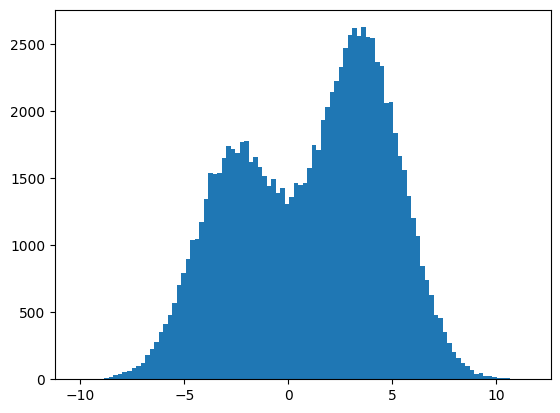

In [ ]:
## Your code can go here.

samples = []
sample_amount = 100000 # TODO make this bigger later
while len(samples) < sample_amount:
    s = np.random.normal(mu_red, sigma_red, sample_amount-len(samples)) # TODO is there a way to optimize this
    u = np.random.uniform(0,1, sample_amount-len(samples))
    d = p_green(s)/(q_red.pdf(s) * M) - u
    ss = pd.Series(s)
    sd = pd.Series(d)
    ss = ss[sd > 0]
    samples = np.concatenate((samples, np.array(ss)))

plt.hist(samples, bins=100)
plt.show()

# Text decoding using Metropolis-Hasting

In this exercise, we will apply the Metropolis-Hastings algorith, to the problem of decoding encoded by substitution, assuming we known the language of the text.

We assume also that we can model this language using bigrams (an order 1 Markov chain on the letters). More formally, this language is written over the alphabet $\Lambda$. For example, in English, $\Lambda$ contains upper and lower case letters, punctuation marks, numbers, etc...

The bigram model is given by $\mu$ and $A$:
 - $\mu$ is the stationnary distribution of single letters probabilities
 - $A$ is the transition matrix between letters: it gives for each letter the probability of the next letter.

This model can easily be estimated from a large corpus of text. An encoding (or decoding) function by substitution is a bijective function $\tau: \Lambda \rightarrow \Lambda$.
If $T′$ is a text, the encoded text $T = \tau(T′)$ is obtained by replacing each letter $c$ of $T′$ by $\tau(c)$.

Our formal problem is thus: given and encoded text $T = (c_1, c_2, . . . . , c_{|T|})$ ($c_i \in \Lambda, \forall i$), retrieve the initial decoded text.

## Preliminaries


1. How do you compute the likelihood of a sequence $T = (c_1, c_2, \cdots, c_{|T|})$ using a bigram model of parameter $(\mu, A)$?

We note the likelihood this way:
$
L(T, \mu, A) = P(c_1, c_2, \ldots, c_{|T|}\mid \mu, A)
$

One way to find the code would be to use simple Monte Carlo and sample encoding functions, using a distribution proportional to the likelihood of the decoded text.

In [113]:
# This assumes, that t is already given as a sequence of indeces
def L(t,mu,A,input_and_output_in_log_space=False):
    # computing the probabilities of the single letters
    #ps = math.prod([mu[t[i]] for i in range(len(t))])
    ps = mu[t[0]]
    # TODO check if we need all of them or just the first

    # computing the probabilities of next letters
    transition_probabilities = [A[t[i]][t[i+1]] for i in range(len(t)-1)]
    pn = np.sum(transition_probabilities) if input_and_output_in_log_space else math.prod(transition_probabilities)

    p = ps + pn if input_and_output_in_log_space else ps * pn

    return p

In [36]:
## Testing
t = [0,1,2]
mu = [0.4,0.3,0.3]
A = np.array(
    [[0.1, 0.1, 0.8],
     [0.8, 0.1, 0.1],
     [0.1, 0.8, 0.1]])
A = A.T
L(t,mu,A)

np.float64(0.25600000000000006)

2. How many encoding functions are there? Is it possible to sample?

An encoding function can be interpreted as a permutation of the characters of the Alphabet (in this case $\Lambda$), because it assigns each character of the alphapet to a random other character from the alphabet, without repeating letters. This means that there are $|\Lambda|!$ many possible encodings. Sampling all of these would take far to much time.

As we cannot sample directly a encoding function we will use MCMC. This method only needs the to know sampling probabilities up to a factor, which is the case here.

We will thus construct a Markov chain on the space of all decoded text, by sampling decoding functions $\tau$.
The Metropolis-Hastings method works as follow:
- Choose an initial state $\tau_0$ arbitrarily
- Repeat $N$ times the following steps:
    - Compute $\tau$ from $\tau_t$ by swapping exactly 2 letters $c_1$ and $c_2$ in the encoding (see below for details on the function)
    - Accept the transition from $\tau_t$ to $\tau$ with the probability $\alpha(\tau_t, \tau)$ :

    $$
    \alpha(\tau_t, \tau) = \min \left( 1, \frac{L(\tau(T), \mu, A)\cdot M(\tau_t,\tau)}
    {L(\tau_t(T), \mu, A)\cdot M(\tau,\tau_t)}\right)
    $$
This mean that ones draw $u \sim \mathcal{U}(0,1)$:

        - if $u < \alpha(\tau_t, \tau)$ then $\tau_{t+1} = \tau$
        - otherwise $\tau_{t+1} = \tau_{t}$


After a sufficient large number of of iterations, the decoding function is drawn according to the probabilities of the decoded text.

3. Show that the log probability of acceptation can be written as:
$$
\begin{align}
\log \alpha(\tau_t, \tau) = \min\Big( 0, & \log \mu(\tau(c_1))  -  \log \mu(\tau_t(c_1)) \\
& + \sum_{i=1}^{|T|-1} \log A(\tau(c_{i}), \tau(c_{i+1}) \\
&  - \sum_{i=1}^{|T|-1} \log  A(\tau_t(c_{i}), \tau_t(c_{i+1}) \Big)
\end{align}
$$


$$
\log \alpha(\tau_t, \tau) = \log \left(\min \left( 1,
\frac{L(\tau(T), \mu, A)\cdot M(\tau_t,\tau)}
{L(\tau_t(T), \mu, A)\cdot M(\tau,\tau_t)}\right)\right)
$$
Since log is monotonically increasing
$$
\log \alpha(\tau_t, \tau) = \min \left( \log(1),
\log\left(\frac{L(\tau(T), \mu, A)\cdot M(\tau_t,\tau)}
{L(\tau_t(T), \mu, A)\cdot M(\tau,\tau_t)}\right)\right)
$$
By the laws of the logarithm
$$
\log \alpha(\tau_t, \tau) = \min \left( 0,
\log\left(\frac{L(\tau(T), \mu, A)\cdot M(\tau_t,\tau)}
{L(\tau_t(T), \mu, A)\cdot M(\tau,\tau_t)}\right)\right)
$$

#TODO WTF happens to M(T,T) and WTF is M

$$
=\min \left( 0, \log\left( \frac{ \mu(\tau(c_1)) \cdot \prod_{i=1}^{|T|-1} A(\tau(c_{i}), \tau(c_{i+1}))}{\mu(\tau_t(c_1)) \cdot \prod_{i=1}^{|T|-1}  A(\tau_t(c_{i}), \tau_t(c_{i+1}))}  \right)\right)
$$

$$
=\min \Big( 0, \log \mu(\tau(c_1))  -  \log \mu(\tau_t(c_1))
 + \sum_{i=1}^{|T|-1} \log A(\tau(c_{i}), \tau(c_{i+1}))
 - \sum_{i=1}^{|T|-1} \log  A(\tau_t(c_{i}), \tau_t(c_{i+1}))\Big)
$$



## Project

1) Download the file `countWar.pkl` which contains the template of bigrams learned from Tolstoy's novel _War and Peace_. This text was chosen because it contains more than 3 million characters, which is long enough to learn a representative model of a language. Also download the `secret.txt` message to decode (or this one `secret2.txt`, same message coded differently in case you would have problems with the first file).

2) Execute the following code to load in python the bigram model and the secret message.

   - The variable `count` is a dictionary: for each letter of the novel _War and Peace_, it provides its number of occurrences in the novel.
   - The pattern of bigrams is described by the variables `mu` and `A`.
   - The variable `mu` is a vector that contains the initial probability distribution over the letters.
   - `A` is a matrix that gives the probabilities of a letter given another letter.
   - `secret` is a variable containing the message to be decoded.

In [79]:
import pickle as pkl

# Open the dictionary
with open("./countWar.pkl", 'rb') as f:
    (count, mu, A) = pkl.load(f, encoding='latin1')

with open("./secret.txt", 'r') as f:
    secret = f.read()[0:-1] # -1 to suppress the line break
with open("./secret2.txt", 'r') as f:
    secret2 = f.read()[0:-1] # -1 to suppress the line break



In [80]:
len(count.keys())

77

3) The decoding functions will be represented as a dictionary where the key and the stored value are both of type character (one letter is encoded/decoded into another letter).
  
Write a function
  ``` swapF : (char,char) dict -> (char,char) dict ``` <br>
which takes as argument a decoding function $\tau_t$ and returns a new decoding function $\tau$ constructed by swapping two letters $c_1$ and $c_2$ as described in the previous question:
 -  $\tau(c)=\tau_t(c)$ for any $c$ such as $c \ne c_1$ and $c \ne c_2$;
 -  $\tau(c_1)=\tau_t(c_2)$
 -  $\tau(c_2)=\tau_t(c_1)$.


You can test your function with the following dictionary:

In [81]:
def swapF(taut):
    """
    """
    random_index1 = np.random.randint(0, len(taut.keys()))
    random_index2 = np.random.randint(0, len(taut.keys())-1)
    if random_index1 >= random_index2:
        random_index2 += 1 # To make shure the indices are different

    random_char1 = list(taut.keys())[random_index1]
    random_char2 = list(taut.keys())[random_index2]

    tau = taut.copy()
    tau[random_char1] = taut[random_char2]
    tau[random_char2] = taut[random_char1]

    return tau



In [82]:
tau = {'a' : 'b', 'b' : 'c', 'c' : 'a', 'd' : 'd' }

In [83]:
swapF(tau)

{'a': 'b', 'b': 'c', 'c': 'a', 'd': 'd'}

4) Write a function `decrypt: string x (char,char) dict -> string` <br>
which, given a `mess` string and a decoding function `tau`, returns the string obtained by decoding `mess` by `tau`.

You can test your function with the following code:

In [84]:
def decrypt(mess, tau):
    """
    """
    decoded_mess = ''.join(tau[c] for c in mess)
    return decoded_mess

In [85]:
tau = {'a' : 'b', 'b' : 'c', 'c' : 'a', 'd' : 'd' }
decrypt ("aabcd", tau )
decrypt ( "babc", tau )

'cbca'

which will produce the following output:

```
>>> decrypt ("aabcd", tau )
 bbcad
>>> decrypt ("dcba", tau )
 dacb
```

5) Create a dictionary (a hash table) associating to each character its index in `mu` or `A`. The code is simply the following:

In [86]:
chars2index = dict(zip(np.array(list(count.keys())), np.arange(len(count.keys()))))


`chars2index['a']` simply gives access to the index corresponding to the letter `a` in `mu` or `A`

If you prefer, you can also use the index file that has already been generated: `fileHash.pkl`

6) Write a function `logLikelihood: string x float np.array x float np.2D-array x (char,int) dict-> string` which, given a `mess` message (string), the arrays `mu` and `A` created in question 2 from `pickle` and the previous dictionary `chars2index`, returns the log-likelihood of the `mess` message with respect to the big diagram model `(mu, A)`.

You can test your function with the following code:

logLikelihood( "abcd", mu, A, chars2index )
logLikelihood( "dcba", mu, A, chars2index )

In [ ]:
def logLikelihood(mess, mu, A, chars2index, inputs_in_log_space=False):
    indices = [chars2index[c] for c in mess]
    loglikelihood = L(indices, mu, A, True) if inputs_in_log_space else math.log(L(indices, mu, A))
    return loglikelihood

In [88]:
logLikelihood( "abcd", mu, A, chars2index )
logLikelihood( "dcba", mu, A, chars2index )

2.0713021389297654e-11
3.881385271016575e-12


-26.274828997400395

which will produce the following output:
```
 >>> logLikelihood( "abcd", mu, A, chars2index )
 -24.600258560804818
 >>> logLikelihood( "dcba", mu, A, chars2index )
 -26.274828997400395
```

7) Code the Metropolis-Hastings method seen in TD as a function called `MetropolisHastings(mess, mu, A, tau, N, chars2index)` using the `swapF`, `decrypt` and `logLikelihood` functions:
  - The `mess` parameter is the coded message.
  - Parameters `mu` and `A` represent the bigram model.
  - The argument `tau` is the initial decoding function to start the Metropolis-Hastings algorithm.
  - The argument `N` is the maximum number of iterations of the algorithm.
  - The argument `chars2index` has already been seen.

The method is a simple loop where we do the following steps:
  - draw a new decoding function `tau'` by applying swapF with the current decoding function tau as parameter
  - calculation of the log-likelihood of the decoded message thanks to `tau'`.
  - draw to accept or not to accept the transition to `tau'` given the the ratio of likelihoods
  - if the transition is accepted, save the decoded message with the highest likelihood.

The function returns the most likely decoded message. You will display the log-likelihood each time it is improved and the decoded message is saved.

the function returns the most likely decoded message. You will display the log-likelihood each time it is improved and the corresponding decoded message so that you can observe the evolution of the algorithm.

In order to test your function, you can execute the following code:

In [124]:
def MetropolisHastings( mess, mu, A, tau, N, chars2index):
    log_mu = np.log(mu)
    log_A = np.log(A)
    new_ll = logLikelihood(decrypt(mess, tau), log_mu, log_A, chars2index, True)
    for i in range(N):
        tau_new = swapF(tau)

        decode = decrypt(mess, tau_new)
        old_ll = new_ll
        new_ll = logLikelihood(decode, log_mu, log_A, chars2index, True)
        print('newll: ', new_ll)

        alpha = min(0, new_ll - old_ll)
        u = np.random.uniform(0,1)

        if math.log(u) < alpha:
            tau = tau_new
    
    return tau

In [102]:
type(mu)

numpy.ndarray

In [ ]:
def identityTau (count):
    tau = {}
    for k in list(count.keys()):
        tau[k] = k
    return tau

#Test run, this will not provide a correct answer.

MetropolisHastings( secret2, mu, A, identityTau (count), 10000, chars2index)

C:\Users\janni\AppData\Local\Temp\ipykernel_24604\759400337.py:10: RuntimeWarning: overflow encountered in scalar multiply
  pn = np.sum(transition_probabilities) if input_and_output_in_log_space else math.prod(transition_probabilities)


inf
inf
newll:  -9379.827224454611
inf
newll:  -9090.415740801685
inf
newll:  -9087.300056617782
inf
newll:  -9087.300056617782
inf
newll:  -9085.729333217529
inf
newll:  -9092.90885596441
inf
newll:  -8857.611407971039
inf
newll:  -9251.283295608186
inf
newll:  -8861.772349374163
inf
newll:  -8861.772349374163
inf
newll:  -8861.772349374163
inf
newll:  -8998.313730557798
inf
newll:  -8861.772349374163
inf
newll:  -8838.588721836475
inf
newll:  -8826.360500162764
inf
newll:  -8821.63329962129
inf
newll:  -8821.63329962129
inf
newll:  -8815.294555599765
inf
newll:  -8682.373380797846
inf
newll:  -8682.373380797846
inf
newll:  -8679.88586586303
inf
newll:  -8748.13298161692
inf
newll:  -8679.88586586303
inf
newll:  -8768.629006806785
inf
newll:  -8687.881381703659
inf
newll:  -8770.655765774403
inf
newll:  -8604.962401787094
inf
newll:  -8944.655959601032
inf
newll:  -8598.013796679663
inf
newll:  -8561.62711914128
inf
newll:  -8564.081565180471
inf
newll:  -8558.438049192195
inf
newll: 

Warning: this (silly) code doesn't work with `secret.txt`, only with `secret2.txt`!

7) To speed up the calculations, we'll start from a decoding function taking the frequencies of occurrence of the letters (i.e. the most frequent letter of the coded message will be decoded to the most frequent letter observed in Tolstoy's novel; then the second most frequent letter of the coded message will be decoded to the second most frequent letter observed in the novel; and so on...). You can use the following code to build such a decoding function, named here `tau_init`.

In [123]:
# WARNING: mu = proba of the init characters, not the stationary proba.
# => find frequent characters = sort (count) !
# stationary character distribution
freqKeys = np.array(list(count.keys()))
freqVal = np.array(list(count.values()))
# character index: +freq => - freq in references
rankFreq = (-freqVal).argsort()

# secret message analysis: index of the most frequent => least frequent
keys = np.array(list(set(secret2))) # all characters of secret2
rankSecret = np.argsort(-np.array([secret2.count(c) for c in keys]))
# ATTENTION: 37 keys in secret, 77 in general...
# Only the most frequent characters of mu are encoded,
# so much the worse for the others.
# alignment of + freq in mu VS + freq in secret
tau_init = dict([(keys[rankSecret[i]], freqKeys[rankFreq[i]]) for i in range(len(rankSecret))])

MetropolisHastings(secret2, mu, A, tau_init, 50000, chars2index)

C:\Users\janni\AppData\Local\Temp\ipykernel_24604\759400337.py:10: RuntimeWarning: overflow encountered in scalar multiply
  pn = np.sum(transition_probabilities) if input_and_output_in_log_space else math.prod(transition_probabilities)


inf
inf
-5147.393908861648
inf
-4933.876484619452
inf
-5395.340824566896
inf
-5407.627950682423
inf
-4946.637317675553
inf
-5507.636704231815
inf
-5022.397868698143
inf
-5022.397868698143
inf
-5050.658742167861
inf
-5275.072209346966
inf
-5003.362222454188
inf
-5220.5494182247
inf
-5111.652810510916
inf
-5257.759352490469
inf
-6257.66238648746
inf
-5283.800965644403
inf
-5151.634676142957
inf
-6063.718146907295
inf
-5401.934561780308
inf
-5639.936882884742
inf
-5547.1447728774665
inf
-5823.743104762825
inf
-5492.8266036463465
inf
-6334.097095518537
inf
-5954.898219422921
inf
-5866.8910500874035
inf
-6181.8016948783115
inf
-5826.305257171709
inf
-5616.447152295932
inf
-6267.213639900649
inf
-5722.482516303132
inf
-5611.4342320592605
inf
-5852.371461061169
inf
-5600.408184682517
inf
-5631.209571394806
inf
-7160.011025291882
inf
-5598.77060325943
inf
-5610.182781780419
inf
-5796.577125812573
inf
-5681.777303509378
inf
-5812.169371693826
inf
-6307.241146493279
inf
-5884.856766737497
inf
-6

KeyboardInterrupt: 


The message will normally be intelligible when you reach a log-likelihood of more than -3090. However, there are usually still some errors in the translation... Do you notice some specific errors and could you explain why they are being observed?

